In [61]:
# Import lib
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# load data
import requests
import io

url = "https://raw.githubusercontent.com/madmanor/lis4893/refs/heads/main/lab7/SMSSpamCollection.txt"
response = requests.get(url)
response.raise_for_status()
text = response.text


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [62]:
df = pd.read_csv(io.StringIO(text), sep='\t', names=['label', 'message'])
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [63]:
# create id column
df['id'] = range(len(df))

print(df.head())

  label                                            message  id
0   ham  Go until jurong point, crazy.. Available only ...   0
1   ham                      Ok lar... Joking wif u oni...   1
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   2
3   ham  U dun say so early hor... U c already then say...   3
4   ham  Nah I don't think he goes to usf, he lives aro...   4


In [64]:
# subset id/text(message) fields
df_subset = df[['id', 'message']].copy()

# remove non alphabet characters
df_subset['message'] = df_subset['message'].str.replace("[^a-zA-Z#]", "   ")

# convert to lower case
df_subset['message'] = df_subset['message'].str.casefold()
print(df_subset.head(10))



   id                                            message
0   0  go until jurong point, crazy.. available only ...
1   1                      ok lar... joking wif u oni...
2   2  free entry in 2 a wkly comp to win fa cup fina...
3   3  u dun say so early hor... u c already then say...
4   4  nah i don't think he goes to usf, he lives aro...
5   5  freemsg hey there darling it's been 3 week's n...
6   6  even my brother is not like to speak with me. ...
7   7  as per your request 'melle melle (oru minnamin...
8   8  winner!! as a valued network customer you have...
9   9  had your mobile 11 months or more? u r entitle...


In [65]:
# staging df for polarity scores
df1 = pd.DataFrame()
df1['id'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [66]:

# Initializing sentiment analysis tool object and running for loops to iterate
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['message']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'id': row['id'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    id sentiment_type  sentiment_score
3    0       compound           0.6249
7    1       compound           0.4767
11   2       compound           0.7964
15   3       compound           0.0000
19   4       compound          -0.1027
23   5       compound           0.8802
27   6       compound          -0.1331
31   7       compound           0.4767
35   8       compound           0.9390
39   9       compound           0.8513


In [67]:
# merge output t_df_cleaned with the input df
df_output = pd.merge(df, t_df_cleaned, on='id', how='inner')
print(df_output.head(10))

  label                                            message  id sentiment_type  \
0   ham  Go until jurong point, crazy.. Available only ...   0       compound   
1   ham                      Ok lar... Joking wif u oni...   1       compound   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   2       compound   
3   ham  U dun say so early hor... U c already then say...   3       compound   
4   ham  Nah I don't think he goes to usf, he lives aro...   4       compound   
5  spam  FreeMsg Hey there darling it's been 3 week's n...   5       compound   
6   ham  Even my brother is not like to speak with me. ...   6       compound   
7   ham  As per your request 'Melle Melle (Oru Minnamin...   7       compound   
8  spam  WINNER!! As a valued network customer you have...   8       compound   
9  spam  Had your mobile 11 months or more? U R entitle...   9       compound   

   sentiment_score  
0           0.6249  
1           0.4767  
2           0.7964  
3           0.0000  
4  

In [68]:
# describe
df_output[["sentiment_score"]].describe()


,sentiment_score
count,5572.000000
mean,0.190868
std,0.411617
min,-0.931900
25%,0.000000
50%,0.000000
75%,0.524200
max,0.997500


In [69]:
# Task 1:

# - What is the 'text' field for your dataset?
#   - The "text" field in my dataset was the sms message column.

# - Which common column did you choose to merge your original dataset with the sentiment scores?
#   - I used the 'id' column to merge because there was no unique id previously to link back to the label.

# - Briefly explain your sentiment polarity results using the `describe` method.
#   - The count shows the total amount of messages analyzed, the mean sentiment score was 0.19, which is a neutral average since its close to 0.
#    -- the min (-0.932) & max (+0.998) show the most extreme polarity of the negative/positive messages

# - Visualize and explain your sentiment results using two different visualization libraries.
#   - Bar Graph comparing mean sentiment of the two types of messages: normal messages(ham) & spam.
#   -- The spam messages have a higher positive sentiment but still relatively neutral, this is because they want to get you to do something.
#   - Boxplot to show spread of data. I couldnt get this to work for some reason but it would have been useful to see the spread of the data.



In [ ]:
#TASK 2 [2 Points]: At the end of your Colab notebook, create a new text cell, and write a brief reflection for this assignment in a few sentences addressing the following:

#What went well? What did not go well, or what challenges did you encounter?
# - Mostly everything went well, there were some things that were different because of how my dataset was structured, it really made it simple. The only thing I couldnt get to work is the second visualization.
#In what ways could sentiment analysis be integrated into your current or future professional or research work?
# - I could see using sentiment analysis in the aviation industry and do SWOT analysis or in accident investigation, to help determine the mental states of the crew. There are endless things that it could be used for.


<Axes: title={'center': 'Average Sentiment of Ham(Real) vs. Spam Messages'}, xlabel='Message Type', ylabel='Mean Sentiment Score'>

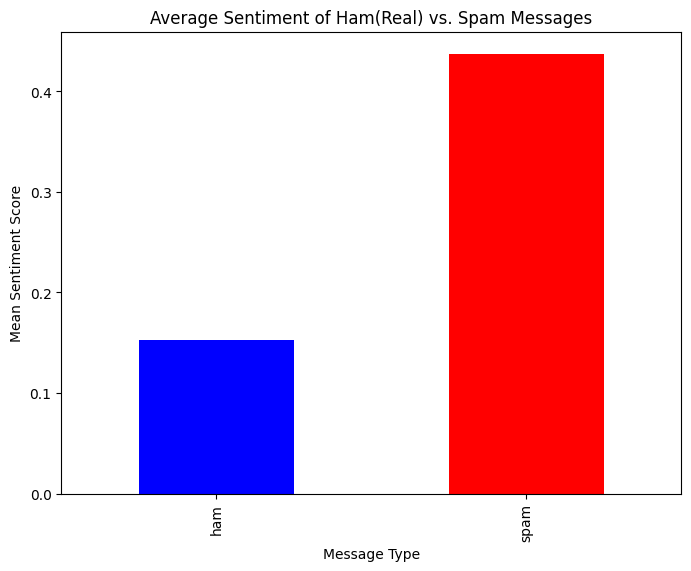

In [70]:
# vizualize: compare the tone of spam vs ham messages
dfg = df_output.groupby(['label'])['sentiment_score'].mean()

dfg.plot(kind='bar',
         title ='Average Sentiment of Ham(Real) vs. Spam Messages',
         ylabel='Mean Sentiment Score',
         xlabel='Message Type',
         figsize=(8, 6),
         color=['blue', 'red'])


In [77]:
import altair as alt

# Boxplot to show spread of data.

chart_boxplot = alt.Chart(df_output).mark_boxplot(extent='min-max',size = 10).encode(
    x=alt.X('label', title='Message Type'),
    y=alt.Y('sentiment_score', title='Sentiment Score'),
    color=alt.Color('label')
    ).properties(
        title= 'Min Max Spread of Senitment Score'
    ).interactive()

chart_boxplot



ImportError: The "vegafusion" data transformer and chart.transformed_data feature requires
version 1.5.0 or greater of the 'vegafusion-python-embed' and 'vegafusion' packages.
These can be installed with pip using:
    pip install "vegafusion[embed]>=1.5.0"
Or with conda using:
    conda install -c conda-forge "vegafusion-python-embed>=1.5.0" "vegafusion>=1.5.0"

ImportError: No module named 'vegafusion'

alt.Chart(...)